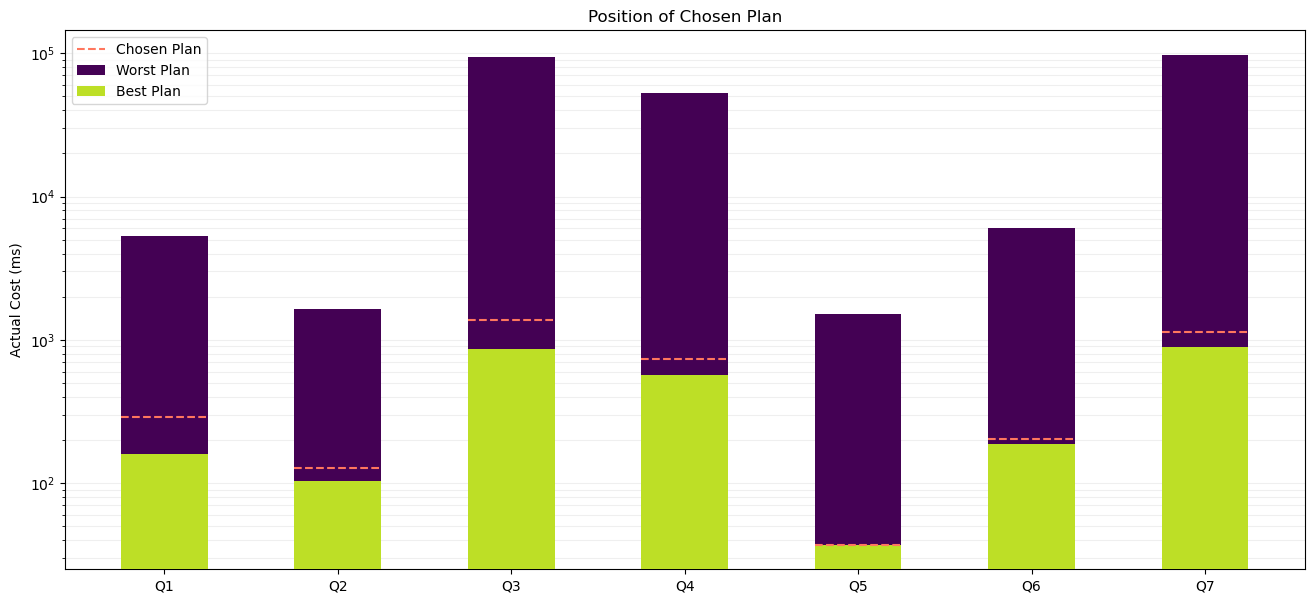

In [22]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data
with open('data/fdbs_performance/winning_plan.json', 'r') as f:
    data = json.load(f)

colors = plt.cm.viridis(np.linspace(0, 0.9, 4))

# Extract metrics
query_labels = []
winning_costs = []
best_costs = []
off_percents = []
chose_winning = []

for i, entry in enumerate(data):
    # Use a short version of the query or index
    query_labels.append(entry['queryShort'])
    
    # Find winning plan cost
    winning_plan = next(p for p in entry['orderedData'] if p['wasWinningPlan'])
    winning_costs.append(winning_plan['actualCost'])
    
    # Find best plan cost (minimum actual cost)
    best_cost = min(p['actualCost'] for p in entry['orderedData'])
    best_costs.append(best_cost)
    
    off_percents.append(entry['offByPercent'])
    
    chose_winning.append(entry['choseWinningPlan'])

# Set up the visualization
x = np.arange(len(query_labels))
width = 0.35

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

# position of winning plan

query_labels = []
low = []
high = []
winning = []

bar_width = 0.5

for i, entry in enumerate(data):
    query_labels.append(entry['queryShort'])
    low.append(entry['orderedData'][0]['actualCost'])
    high.append(entry['orderedData'][-1]['actualCost'])
    for x, measuredResult in enumerate(entry['orderedData']):
        if measuredResult['wasWinningPlan']:
            winning.append(measuredResult['actualCost'])

ax.yaxis.grid(True, which="both", ls="-", alpha=0.2, zorder=1)
ax.bar(query_labels, high, bar_width, label='Worst Plan', color=colors[0], zorder=2)
ax.bar(query_labels, low, bar_width, label='Best Plan', color=colors[3], zorder=3)

need_legend = True
for i in range(len(winning)):
    legend = 'Chosen Plan' if need_legend else None
    need_legend = False
    ax.hlines(y=winning[i], xmin=i-(bar_width / 2), xmax=i+(bar_width / 2), colors=['#ff775e'], linestyles=['dashed'], label=legend, zorder=4)


ax.set_yscale('log')
ax.set_title('Position of Chosen Plan')
ax.set_ylabel('Actual Cost (ms)')
ax.legend()

plt.savefig('images/winning/winning_bar.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


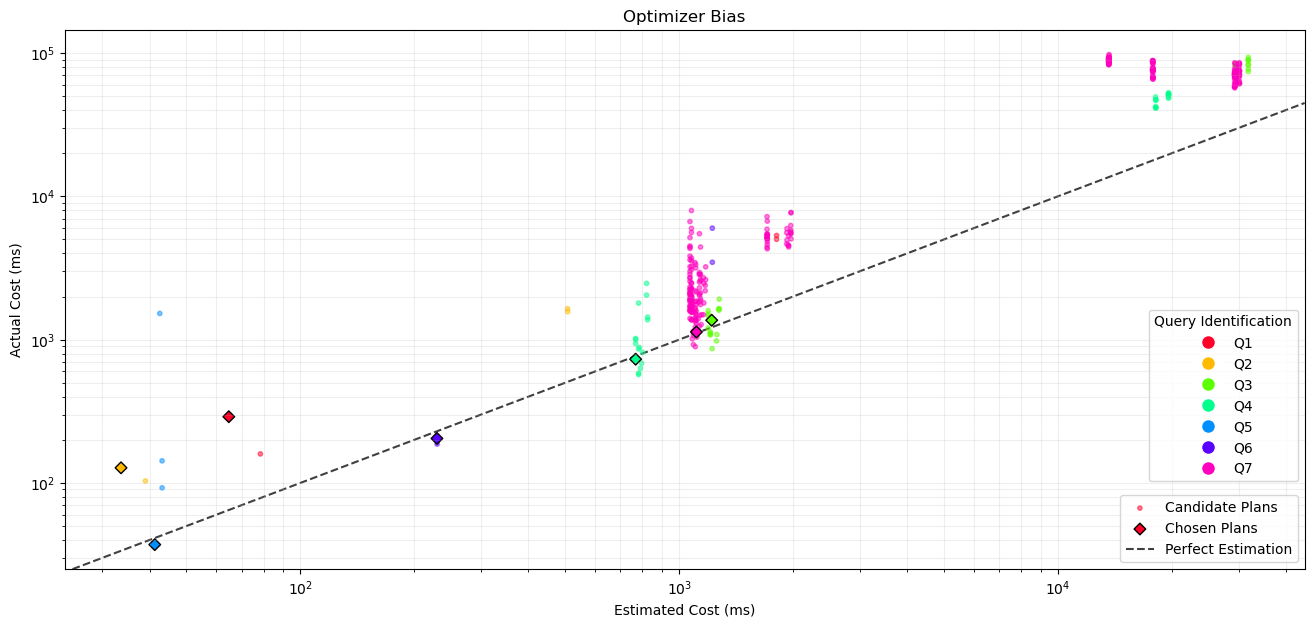

In [23]:
from matplotlib.lines import Line2D

# Flatten data for analysis of all plans across all queries
all_plans = []
for i, query_entry in enumerate(data):
    for plan in query_entry['orderedData']:
        all_plans.append({
            'query_id': i,
            'query_short': query_entry['queryShort'],
            'estimated_cost': plan['estimated_cost' if 'estimated_cost' in plan else 'estimatedCost'],
            'actual_cost': plan['actual_cost' if 'actual_cost' in plan else 'actualCost'],
            'is_winning_plan': plan['wasWinningPlan'],
            'join_type': 'HASH' if 'HASH' in plan['joinPlan'] else 'NESTED LOOP',
        })

df = pd.DataFrame(all_plans)
colors = plt.cm.gist_rainbow(np.linspace(0, 1, 7))

fig, ax = plt.subplots(figsize=(16, 7))

for name, group in df.groupby('is_winning_plan'):
    label = "Chosen Plans" if name else "Candidate Plans"
    marker = 'D' if name else 'o'
    alpha = 1 if name else 0.5
    size = 35 if name else 10
    border = 'black' if name else None
    ax.scatter(group['estimated_cost'], group['actual_cost'], label=label, marker=marker, alpha=alpha, color=colors[group['query_id']], s=size, edgecolors=border)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]

ax.axline((0, 0), slope=1, color='k', linestyle='--', alpha=0.75, zorder=0, label='Perfect Estimation')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Estimated Cost (ms)')
ax.set_ylabel('Actual Cost (ms)')
ax.set_title('Optimizer Bias')
ax.grid(True, which="both", ls="-", alpha=0.2)

first_legend = ax.legend(loc='lower right')
ax.add_artist(first_legend)

color_proxies = [Line2D([0], [0], marker='o', color='w', 
                 markerfacecolor=colors[i], markersize=10, label=query_labels[i]) 
                 for i in range(len(query_labels))]
ax.legend(handles=color_proxies, title="Query Identification", loc='lower right', bbox_to_anchor=(1, 0.15))


plt.savefig('images/winning/optimizer_bias.png', bbox_inches='tight', pad_inches=0.1)